# Generate Samples from Conditional Diffusion Model

This notebook loads a trained Conditional Diffusion Model and a VAE, generates latent samples from the test set, and decodes them into 3D CT images.

**NOTE**: This notebook is split into two parts to manage GPU memory. 
1. **Generation**: Generates latent representations and saves them to disk.
2. **Decoding**: Loads saved latents and decodes them to images using VAE. 

**Please restart the kernel between Part 1 and Part 2.**

In [1]:
import os
import sys
import glob
import json
import torch
import numpy as np
import nibabel as nib
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from monai.utils import set_determinism
from monai.networks.nets import DiffusionModelUNet
from diffusers import DDPMScheduler

set_determinism(42)

## Configuration (Part 1)

In [ ]:
config = {
    "data_dir": "/net/tscratch/people/plgpiotreksl/maisi_vae_latent",
    "output_dir": "/net/tscratch/people/plgpiotreksl/generated_samples",
    "diffusion_checkpoint": "/net/tscratch/people/plgpiotreksl/models/conditional_diffusion_unetv2/model_best.pt",
    "vae_checkpoint": "/net/people/plgrid/plgpiotreksl/jupyter/models/autoencoder_epoch273.pt",
    "batch_size": 1,
    "num_inference_steps": 1000,  # DDPMScheduler steps (full inference)
    "num_samples_per_patient": 10,
    "spatial_dims": 3,
    "latent_channels": 4,
    "model_channels": (64, 128, 256, 512),
    "attention_levels": (False, False, True, True),
    "num_res_blocks": 2,
    "num_head_channels": 64,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

# Create output directories
os.makedirs(os.path.join(config["output_dir"], "latents"), exist_ok=True)
os.makedirs(os.path.join(config["output_dir"], "images"), exist_ok=True)

print(f"Using device: {config['device']}")

Using device: cuda


## Dataset Definition
Modified to return one item per patient (just fraction 1).

In [3]:
class PatientConditionDataset(Dataset):
    """Dataset that returns fraction_1 (condition) for each patient."""
    
    def __init__(self, root_dir, patient_split=None):
        self.root_dir = root_dir
        self.samples = []
        
        # Get all patient directories
        patient_dirs = sorted(glob.glob(os.path.join(root_dir, "Patient_*")))
        
        # If split is provided, filter patients
        if patient_split is not None:
            filtered_dirs = []
            for p_dir in patient_dirs:
                p_id = os.path.basename(p_dir).split("_")[1]
                if p_id in patient_split:
                    filtered_dirs.append(p_dir)
            patient_dirs = filtered_dirs
            
        for p_dir in patient_dirs:
            # Find all fractions for this patient
            fractions = sorted(glob.glob(os.path.join(p_dir, "*.pt")))
            
            # Find fraction 1
            f1_path = None
            for f in fractions:
                if "fraction_1_" in os.path.basename(f):
                    f1_path = f
                    break
            
            if f1_path is None:
                continue
                
            self.samples.append(f1_path)
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        f1_path = self.samples[idx]
        
        # Load latents
        f1_data = torch.load(f1_path, map_location="cpu")
        
        # Handle dictionary or tensor
        if isinstance(f1_data, dict):
            f1 = f1_data.get('latent', f1_data.get('z', list(f1_data.values())[0]))
        else:
            f1 = f1_data
            
        # Ensure float32
        f1 = f1.float()
        
        # Squeeze batch dim if present [1, C, D, H, W] -> [C, D, H, W]
        if len(f1.shape) == 5:
            f1 = f1.squeeze(0)
            
        return f1, f1_path

## Data Loading & Splits

In [4]:
# Use specific test patient IDs provided by user
test_ids = {'02', '03', '17', '24', '25', '27', '33', '42', '48', '57', '59', '68', '71', '76', '77'}

print(f"Test patients: {len(test_ids)}")
print(f"Test IDs: {sorted(test_ids)}")

# Create Dataset for test patients only
test_ds = PatientConditionDataset(config["data_dir"], test_ids)

print(f"Test patients found in dataset: {len(test_ds)}")

# Create DataLoader
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

Test patients: 15
Test IDs: ['02', '03', '17', '24', '25', '27', '33', '42', '48', '57', '59', '68', '71', '76', '77']
Test patients found in dataset: 15


## Latent Scaling Calculation

In [5]:
# Hardcoded from training logic/user input
LATENT_SCALE_FACTOR = 2.2562
print(f"Using LATENT_SCALE_FACTOR: {LATENT_SCALE_FACTOR}")

Using LATENT_SCALE_FACTOR: 2.2562


## Diffusion Model Definition (Part 1)

In [6]:
device = torch.device(config['device'])

# 1. Diffusion Model
diffusion_model = DiffusionModelUNet(
    spatial_dims=config["spatial_dims"],
    in_channels=config["latent_channels"] * 2,  # 4 for input + 4 for condition
    out_channels=config["latent_channels"],
    channels=config["model_channels"],
    attention_levels=config["attention_levels"],
    num_res_blocks=config["num_res_blocks"],
    num_head_channels=config["num_head_channels"],
).to(device)

# Load Diffusion Checkpoint
if os.path.exists(config["diffusion_checkpoint"]):
    print(f"Loading Diffusion checkpoint: {config['diffusion_checkpoint']}")
    state_dict = torch.load(config["diffusion_checkpoint"], map_location="cpu")
    
    # Handle DataParallel keys
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            new_state_dict[k.replace("module.", "")] = v
        else:
            new_state_dict[k] = v
            
    diffusion_model.load_state_dict(new_state_dict)
    print("Diffusion model loaded successfully.")
else:
    raise FileNotFoundError(f"Checkpoint not found: {config['diffusion_checkpoint']}")

diffusion_model.eval()

# 2. Scheduler
scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="sample",
    clip_sample=False
)

Loading Diffusion checkpoint: /net/tscratch/people/plgpiotreksl/models/conditional_diffusion_unetv2/model_best.pt
Diffusion model loaded successfully.


## Generation Function

In [7]:
def generate_sample(f1, diffusion_model, scheduler, device, scale_factor):
    """Generates a sample using Diffusion Model."""
    f1 = f1.to(device)
    
    # Scale input condition
    f1_scaled = f1 * scale_factor
    
    # Initialize noisy latent
    latent_shape = f1.shape  # Should be [1, 4, 120, 120, 32] or similar
    latent_noisy = torch.randn(latent_shape, device=device)
    
    # Inference Loop
    with torch.no_grad():
        for t in tqdm(scheduler.timesteps, desc="Sampling", leave=False):
            # Concatenate [Noisy Latent, Condition]
            model_input = torch.cat([latent_noisy, f1_scaled], dim=1)
            
            # Predict
            model_output = diffusion_model(model_input, timesteps=torch.tensor([t], device=device))
            
            # Step
            latent_noisy = scheduler.step(model_output, t, latent_noisy).prev_sample
            
    # Unscale
    generated_latent = latent_noisy / scale_factor
    return generated_latent

## PART 1: Generation Loop
Run this to generate latents. Then restart kernel.

In [ ]:
# Generate samples for test patients only
samples_per_patient = 10

print(f"\nStarting inference on test set with {samples_per_patient} samples per patient...")

for i, batch in enumerate(tqdm(test_loader, desc="Test patients")):
    f1, f1_path = batch
    
    # Extract ID for filename
    patient_id = os.path.basename(os.path.dirname(f1_path[0])).split("_")[1]
    
    # Generate Multiple Samples per Patient
    for sample_idx in range(samples_per_patient):
        base_filename = f"Patient_{patient_id}_sample_{sample_idx+1}"
        latent_save_path = os.path.join(config["output_dir"], "latents", f"{base_filename}.pt")

        if os.path.exists(latent_save_path):
             print(f"Skipping {base_filename}, already exists.")
             continue
        
        # 1. Generate Latent
        print(f"Generating {base_filename}...")
        generated_latent = generate_sample(f1, diffusion_model, scheduler, device, LATENT_SCALE_FACTOR)
        
        # 2. Save Latent
        torch.save(generated_latent.cpu(), latent_save_path)

print("Generation Complete. Please RESTART the kernel now to free GPU memory for decoding.")

# PART 2: Decoding
**RESTART KERNEL BEFORE RUNNING THIS CELL**

This cell is self-contained. It re-loads necessary libraries and the VAE model, then finds all generated latents and decodes them.

In [5]:
# ==========================================
# PART 2: DECODING (Run after kernel restart)
# ==========================================
import os
import sys
import glob
import torch
import numpy as np
import nibabel as nib
from argparse import Namespace
from tqdm import tqdm

# Add MAISI scripts to path for VAE
sys.path.append('/net/people/plgrid/plgpiotreksl/maisi/scripts')
from monai.apps.generation.maisi.networks.autoencoderkl_maisi import AutoencoderKlMaisi
from utils import define_instance

# Re-define Config (simplified for Decoding)
config = {
    "output_dir": "/net/tscratch/people/plgpiotreksl/generated_samples",
    "vae_checkpoint": "/net/people/plgrid/plgpiotreksl/jupyter/models/autoencoder_epoch273.pt",
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

device = torch.device(config['device'])
print(f"Using device: {config['device']}")

# 1. Load VAE Model
print("Loading MAISI VAE model...")
vae_args = Namespace()
vae_args.autoencoder_def = {
    "_target_": "monai.apps.generation.maisi.networks.autoencoderkl_maisi.AutoencoderKlMaisi",
    "spatial_dims": 3,
    "in_channels": 1,
    "out_channels": 1,
    "latent_channels": 4,
    "num_channels": [64, 128, 256],
    "num_res_blocks": [2, 2, 2],
    "norm_num_groups": 32,
    "norm_eps": 1e-06,
    "attention_levels": [False, False, False],
    "with_encoder_nonlocal_attn": False,
    "with_decoder_nonlocal_attn": False,
    "use_checkpointing": False,
    "use_convtranspose": False,
    "save_mem": True,
    "norm_float16": False,
    "num_splits": 32,
    "dim_split": 0
}

vae = define_instance(vae_args, "autoencoder_def").to(device)

if os.path.exists(config["vae_checkpoint"]):
    vae_state_dict = torch.load(config["vae_checkpoint"], map_location=device)
    vae.load_state_dict(vae_state_dict)
    print(f"VAE model loaded from: {config['vae_checkpoint']}")
else:
    raise FileNotFoundError(f"VAE checkpoint not found: {config['vae_checkpoint']}")

vae.eval()

def decode_latent(latent, vae, device):
    """Decodes latent to image using VAE."""
    latent = latent.to(device)
    with torch.no_grad():
        # The MAISI VAE decode expects [B, C, spatial]
        # Ensure float32 or match model precision if needed. Script says float16 sometimes but we use defaults.
        with torch.cuda.amp.autocast(enabled=True):
            decoded_image = vae.decode(latent)
            
        if isinstance(decoded_image, tuple):
            decoded_image = decoded_image[0]
            
    return decoded_image

# 2. Find Latents and Decode
latents_dir = os.path.join(config["output_dir"], "latents")
images_dir = os.path.join(config["output_dir"], "images")
os.makedirs(images_dir, exist_ok=True)

latent_files = sorted(glob.glob(os.path.join(latents_dir, "*.pt")))
print(f"Found {len(latent_files)} latent files to decode.")

decoded_images_list = []

for latent_path in tqdm(latent_files, desc="Decoding"):
    base_name = os.path.basename(latent_path).replace(".pt", "")
    output_nifti_path = os.path.join(images_dir, f"{base_name}.nii.gz")
    
    # Load latent
    latent = torch.load(latent_path, map_location="cpu")
    
    # Ensure shape is [1, C, D, H, W]
    if len(latent.shape) == 4:
        latent = latent.unsqueeze(0)
        
    # Decode
    try:
        # Check if already exists to skip decoding if needed (optional)
        # But we want to populate decoded_images_list for visualization
        if os.path.exists(output_nifti_path):
            decoded_images_list.append((base_name, output_nifti_path))
            continue

        decoded_image = decode_latent(latent, vae, device)
        
        # Save NIfTI
        img_data = decoded_image.squeeze().cpu().float().numpy()
        nifti_img = nib.Nifti1Image(img_data, affine=np.eye(4))
        nib.save(nifti_img, output_nifti_path)
        
        decoded_images_list.append((base_name, output_nifti_path))
        
    except Exception as e:
        print(f"Error decoding {base_name}: {e}")

print("Decoding Complete!")

Using device: cuda
Loading MAISI VAE model...
VAE model loaded from: /net/people/plgrid/plgpiotreksl/jupyter/models/autoencoder_epoch273.pt
Found 333 latent files to decode.


Decoding:   0%|          | 0/333 [00:00<?, ?it/s]/net/tscratch/people/plgpiotreksl/slurm_jobdir/2379616/tmp.t0037/ipykernel_2266001/2270487551.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
Decoding: 100%|██████████| 333/333 [48:35<00:00,  8.76s/it]

Decoding Complete!


## 3. Visualization (Pre-Rescaling)
Displaying middle slices of the decoded images (before rescaling).

Visualizing generated samples (non-rescaled)...


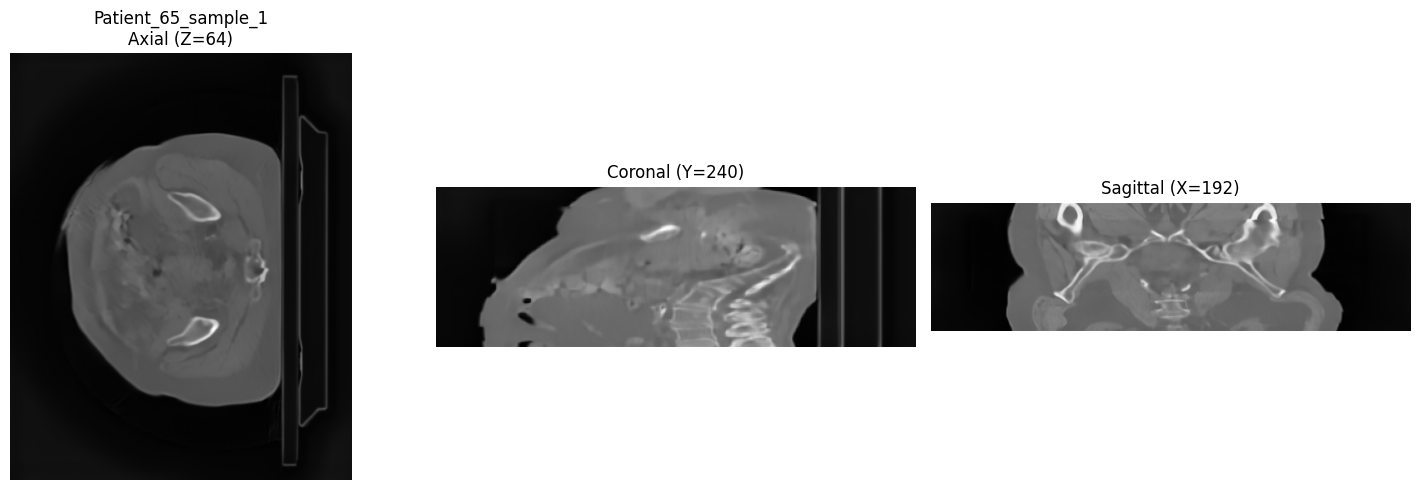

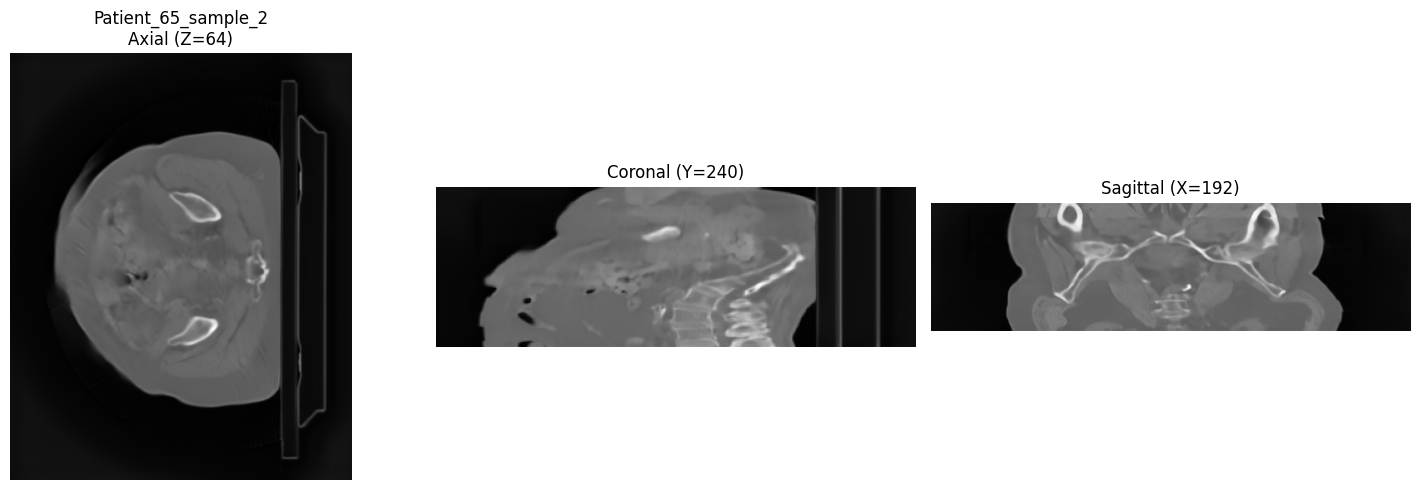

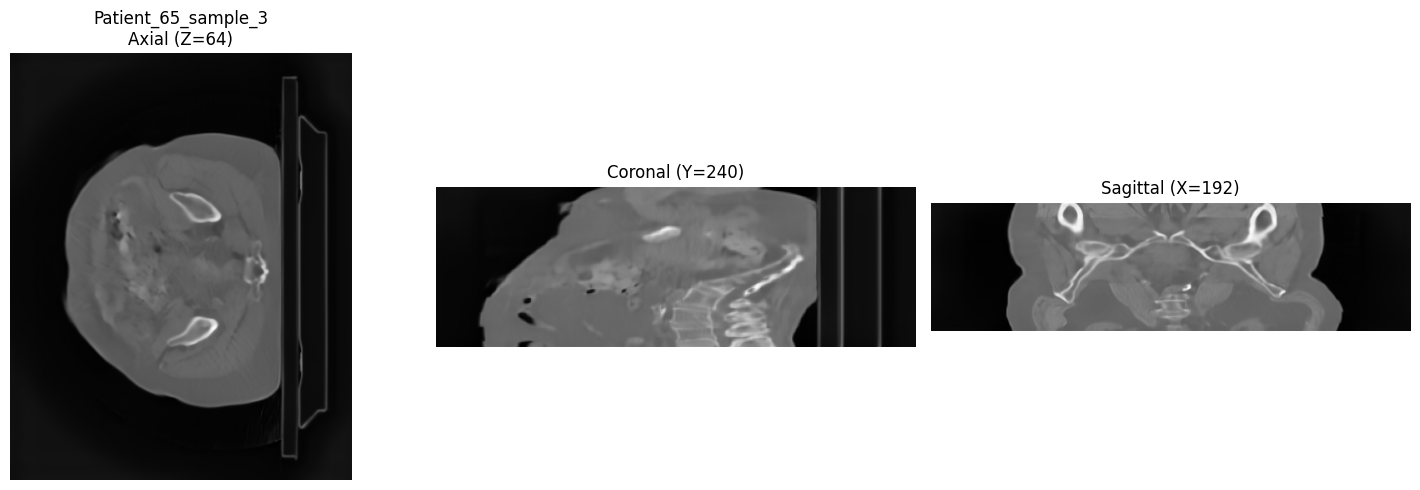

In [2]:
import matplotlib.pyplot as plt

def plot_slices(volume, title="Image"):
    """Plots middle slices of a 3D volume (Axial, Coronal, Sagittal)."""
    nx, ny, nz = volume.shape
    slice_x = nx // 2
    slice_y = ny // 2
    slice_z = nz // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Axial (Z) - X vs Y
    axes[0].imshow(volume[:, :, slice_z].T, cmap='gray', origin='lower')
    axes[0].set_title(f"{title}\nAxial (Z={slice_z})")
    axes[0].axis('off')
    
    # Coronal (Y) - X vs Z
    axes[1].imshow(volume[:, slice_y, :].T, cmap='gray', origin='lower')
    axes[1].set_title(f"Coronal (Y={slice_y})")
    axes[1].axis('off')
    
    # Sagittal (X) - Y vs Z
    axes[2].imshow(volume[slice_x, :, :].T, cmap='gray', origin='lower')
    axes[2].set_title(f"Sagittal (X={slice_x})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize first few decoded images
print("Visualizing generated samples (non-rescaled)...")
for base_name, img_path in decoded_images_list[:3]:
    img = nib.load(img_path).get_fdata()
    plot_slices(img, title=base_name)

## 4. Rescaling to Original Resolution
Rescaling generated images to the original patient input resolution using `monai.transforms.Resize`.

In [6]:
import json
from monai.transforms import Resize

# Load encoding summary to get original shapes
encoding_summary_path = "/net/tscratch/people/plgpiotreksl/maisi_vae_latent/encoding_summary.json"
if os.path.exists(encoding_summary_path):
    with open(encoding_summary_path, "r") as f:
        encoding_summary = json.load(f)
    print(f"Loaded encoding summary.")
else:
    raise FileNotFoundError(f"Summary file not found: {encoding_summary_path}")

# Helper to find original shape for a patient
def get_original_shape(patient_id, summary_data):
    """Finds original_shape of fraction 1 for the given Patient ID."""
    
    # Check if we have the root dict with patient_stats
    if isinstance(summary_data, dict) and "patient_stats" in summary_data:
        patients_list = summary_data["patient_stats"]
    else:
        print("Error: Unexpected JSON structure (expected 'patient_stats' key)")
        return None
        
    for p_entry in patients_list:
        if p_entry.get("patient_id") == patient_id:
            # Found patient, search fractions
            # Look for fraction 1
            for frac in p_entry.get("fractions", []):
                if "fraction_1_" in frac.get("name", ""):
                     return frac["original_shape"]
                     
            print(f"Warning: Fraction 1 not found for Patient {patient_id}")
            return None
            
    print(f"Warning: Patient {patient_id} not found in summary")
    return None

rescaled_images_dir = os.path.join(config["output_dir"], "images_rescaled")
os.makedirs(rescaled_images_dir, exist_ok=True)

rescaled_images_list = []

for base_name, img_path in tqdm(decoded_images_list, desc="Rescaling"):
    # Extract Patient ID from filename: Patient_XXX_...
    try:
        patient_id = base_name.split("_")[1]
    except IndexError:
        print(f"Error parsing patient ID from {base_name}")
        continue
    
    org_shape = get_original_shape(patient_id, encoding_summary)
    
    if org_shape is None:
        print(f"Warning: Could not find original shape for Patient {patient_id}. Skipping rescaling.")
        continue
        
    # Load Image
    nifti_img = nib.load(img_path)
    img_data = nifti_img.get_fdata()
    
    # Rescale - Add channel dim [C, D, H, W] for MONAI
    img_tensor = torch.tensor(img_data).unsqueeze(0)
    
    # Resize transform
    resizer = Resize(spatial_size=org_shape, mode="trilinear")
    rescaled_tensor = resizer(img_tensor)
    
    rescaled_data = rescaled_tensor.squeeze(0).numpy()
    
    # Save Rescaled
    save_path = os.path.join(rescaled_images_dir, f"{base_name}_rescaled.nii.gz")
    new_nifti = nib.Nifti1Image(rescaled_data, affine=nifti_img.affine) 
    nib.save(new_nifti, save_path)
    
    rescaled_images_list.append((base_name, save_path))
    
print("Rescaling Complete!")

Loaded encoding summary.


Rescaling:   0%|          | 0/333 [00:00<?, ?it/s]

Rescaling: 100%|██████████| 333/333 [36:28<00:00,  6.57s/it]

Rescaling Complete!


## 6. Restore Original HU Values
The generated images are in [0, 1] range due to normalization during encoding.
We need to reverse the `ScaleIntensityRanged(a_min=-1000, a_max=1000, b_min=0, b_max=1)` transform.

Formula: `HU_value = normalized_value * (a_max - a_min) + a_min = normalized_value * 2000 - 1000`

In [ ]:
# Parameters matching encode_maisi_vae.py ScaleIntensityRanged transform
HU_MIN = -1000  # a_min in encoding
HU_MAX = 1000   # a_max in encoding
NORM_MIN = 0    # b_min in encoding  
NORM_MAX = 1    # b_max in encoding

def restore_hu_values(normalized_image, hu_min=HU_MIN, hu_max=HU_MAX):
    """
    Reverse the ScaleIntensityRanged transform to restore original HU values.
    
    Original transform: normalized = (HU - hu_min) / (hu_max - hu_min)
    Inverse: HU = normalized * (hu_max - hu_min) + hu_min
    """
    hu_range = hu_max - hu_min  # 2000
    restored = normalized_image * hu_range + hu_min
    return restored

# Create output directory for HU-restored images
hu_images_dir = os.path.join(config["output_dir"], "images_hu")
os.makedirs(hu_images_dir, exist_ok=True)

# Load rescaled images from directory
rescaled_dir = os.path.join(config["output_dir"], "images_rescaled")
rescaled_files = sorted(glob.glob(os.path.join(rescaled_dir, "*.nii.gz")))

print(f"Found {len(rescaled_files)} rescaled images to restore HU values.")
print(f"Transform: [0, 1] -> [{HU_MIN}, {HU_MAX}] HU")

hu_restored_list = []

for img_path in tqdm(rescaled_files, desc="Restoring HU values"):
    base_name = os.path.basename(img_path).replace("_rescaled.nii.gz", "")
    output_path = os.path.join(hu_images_dir, f"{base_name}_hu.nii.gz")
    
    # Load normalized image
    nifti_img = nib.load(img_path)
    img_data = nifti_img.get_fdata()
    
    # Print stats before (for first image only)
    if len(hu_restored_list) == 0:
        print(f"\nBefore HU restoration ({base_name}):")
        print(f"  Min: {img_data.min():.2f}, Max: {img_data.max():.2f}")
        print(f"  Mean: {img_data.mean():.2f}, Std: {img_data.std():.2f}")
    
    # Restore HU values
    hu_data = restore_hu_values(img_data)
    
    # Print stats after (for first image only)
    if len(hu_restored_list) == 0:
        print(f"\nAfter HU restoration ({base_name}):")
        print(f"  Min: {hu_data.min():.2f}, Max: {hu_data.max():.2f}")
        print(f"  Mean: {hu_data.mean():.2f}, Std: {hu_data.std():.2f}")
    
    # Save with original affine
    hu_nifti = nib.Nifti1Image(hu_data.astype(np.float32), affine=nifti_img.affine)
    nib.save(hu_nifti, output_path)
    
    hu_restored_list.append((base_name, output_path))

print(f"\nHU Restoration Complete!")
print(f"Saved {len(hu_restored_list)} images to: {hu_images_dir}")